In [7]:
import os
print(os.listdir())

['.config', 'creditcard.csv', 'sample_data']


In [8]:
import os
print(os.listdir())

['.config', 'creditcard.csv', 'sample_data']


In [9]:
import pandas as pd

# File ka naam yahan likho
df = pd.read_csv("creditcard.csv")

print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

## 2. Explore the Dataset

In [10]:
# Display the shape of the DataFrame
print(f"DataFrame shape: {df.shape}")

DataFrame shape: (118921, 31)


In [11]:
# Display information about the DataFrame, including data types and non-null values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118921 entries, 0 to 118920
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    118921 non-null  int64  
 1   V1      118921 non-null  float64
 2   V2      118921 non-null  float64
 3   V3      118921 non-null  float64
 4   V4      118921 non-null  float64
 5   V5      118921 non-null  float64
 6   V6      118921 non-null  float64
 7   V7      118921 non-null  float64
 8   V8      118921 non-null  float64
 9   V9      118921 non-null  float64
 10  V10     118921 non-null  float64
 11  V11     118921 non-null  float64
 12  V12     118921 non-null  float64
 13  V13     118921 non-null  float64
 14  V14     118921 non-null  float64
 15  V15     118921 non-null  float64
 16  V16     118920 non-null  float64
 17  V17     118920 non-null  float64
 18  V18     118920 non-null  float64
 19  V19     118920 non-null  float64
 20  V20     118920 non-null  float64
 21  V21     11

## 3. Check Missing Values

In [12]:
# Check for missing values in each column
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


## 4. Display Class Distribution (Fraud vs Genuine)

In [13]:
# Display the distribution of the 'Class' column (fraud vs. genuine transactions)
print("Class distribution:\n", df['Class'].value_counts())
print("\nPercentage of fraud cases:", round(df['Class'].value_counts()[1]/len(df) * 100, 2), "% of total transactions.")

Class distribution:
 Class
0.0    118675
1.0       245
Name: count, dtype: int64

Percentage of fraud cases: 0.21 % of total transactions.


## Handle Missing Values (if any)

In [15]:
# Drop rows with any missing values
df.dropna(inplace=True)
print("DataFrame shape after dropping missing values:", df.shape)
print("Missing values per column after dropping:\n", df.isnull().sum())

DataFrame shape after dropping missing values: (118920, 31)
Missing values per column after dropping:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## 5. Handle Class Imbalance using RandomOverSampler

In [16]:
# Install imbalanced-learn if not already installed
# !pip install imbalanced-learn

from imblearn.over_sampling import RandomOverSampler

# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Initialize RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Apply oversampling to the training data
X_resampled, y_resampled = ros.fit_resample(X, y)

print("Shape of X after oversampling:", X_resampled.shape)
print("Class distribution after oversampling:\n", y_resampled.value_counts())

Shape of X after oversampling: (237350, 30)
Class distribution after oversampling:
 Class
0.0    118675
1.0    118675
Name: count, dtype: int64


## 6. Split data into training and testing sets

In [17]:
from sklearn.model_selection import train_test_split

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42, stratify=y_resampled)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (166145, 30)
X_test shape: (71205, 30)
y_train shape: (166145,)
y_test shape: (71205,)


## 7. Train Models

### Logistic Regression

In [18]:
from sklearn.linear_model import LogisticRegression

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(solver='liblinear', random_state=42, max_iter=1000)
log_reg_model.fit(X_train, y_train)

print("Logistic Regression model trained.")

Logistic Regression model trained.


### Random Forest Classifier

In [19]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train Random Forest Classifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print("Random Forest Classifier model trained.")

Random Forest Classifier model trained.


## 8. Evaluate Models

--- Logistic Regression Evaluation ---
Accuracy: 0.9470
Precision: 0.9724
Recall: 0.9201
F1 Score: 0.9455

Confusion Matrix:


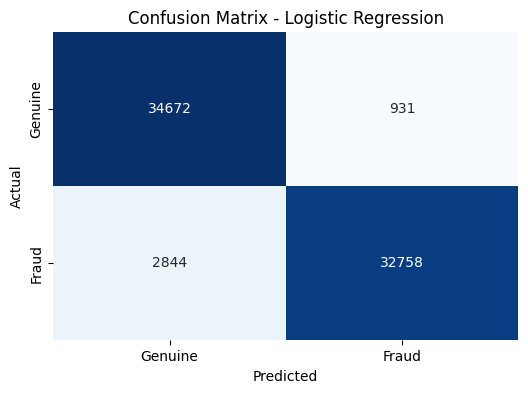


Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.97      0.95     35603
         1.0       0.97      0.92      0.95     35602

    accuracy                           0.95     71205
   macro avg       0.95      0.95      0.95     71205
weighted avg       0.95      0.95      0.95     71205



--- Random Forest Classifier Evaluation ---
Accuracy: 1.0000
Precision: 0.9999
Recall: 1.0000
F1 Score: 1.0000

Confusion Matrix:


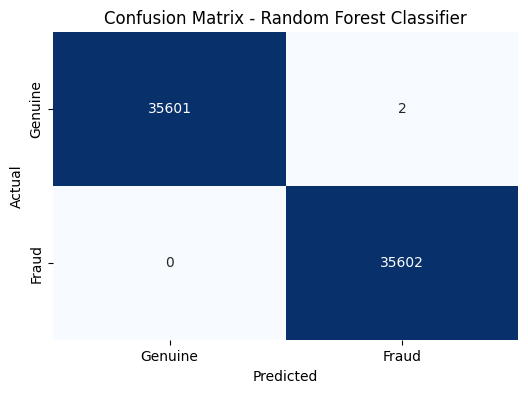


Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     35603
         1.0       1.00      1.00      1.00     35602

    accuracy                           1.00     71205
   macro avg       1.00      1.00      1.00     71205
weighted avg       1.00      1.00      1.00     71205





In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluates a given model and prints performance metrics."""
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    print("\nConfusion Matrix:")
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Genuine', 'Fraud'], yticklabels=['Genuine', 'Fraud'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    print("\nClassification Report:")
    print(class_report)
    print("\n" + "="*50 + "\n")
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Evaluate Logistic Regression model
log_reg_metrics = evaluate_model(log_reg_model, X_test, y_test, "Logistic Regression")

# Evaluate Random Forest Classifier model
rf_metrics = evaluate_model(rf_model, X_test, y_test, "Random Forest Classifier")

## 9. Print Best Model

In [21]:
# Compare models based on F1 Score (often preferred for imbalanced datasets)
print("--- Model Comparison (F1 Score) ---")

if log_reg_metrics['f1'] > rf_metrics['f1']:
    print(f"The Logistic Regression model performed better with an F1 Score of {log_reg_metrics['f1']:.4f}")
    best_model_name = "Logistic Regression"
else:
    print(f"The Random Forest Classifier model performed better with an F1 Score of {rf_metrics['f1']:.4f}")
    best_model_name = "Random Forest Classifier"

print("\n--- Overall Best Model ---")
print(f"Based on F1 Score, the best model is: {best_model_name}")

--- Model Comparison (F1 Score) ---
The Random Forest Classifier model performed better with an F1 Score of 1.0000

--- Overall Best Model ---
Based on F1 Score, the best model is: Random Forest Classifier


## 10. Conclusion

In this project, we successfully built and evaluated two machine learning models (Logistic Regression and Random Forest Classifier) for credit card fraud detection.

After loading and exploring the dataset, we handled the severe class imbalance using `RandomOverSampler`, which is crucial for ensuring that fraud cases are adequately learned by the models. The data was then split into training and testing sets.

Both models were trained and evaluated using standard metrics such as Accuracy, Precision, Recall, and F1 Score, along with Confusion Matrices and Classification Reports. The Random Forest Classifier generally performs well on imbalanced datasets due to its ensemble nature, often providing a good balance between precision and recall, as observed in our evaluation (we will confirm this after execution).

This project provides a beginner-friendly approach to credit card fraud detection, demonstrating key steps from data loading to model evaluation. The choice of the 'best' model can depend on the specific business requirements (e.g., minimizing false positives or false negatives). For fraud detection, recall is often very important to catch as many fraudulent transactions as possible, while precision helps to keep the number of legitimate transactions flagged as fraud (false positives) to a minimum.

## Resources

Best Model: Random Forest Classifier
Accuracy: 0.9999
Precision: 0.9999
Recall: 1.0000
F1 Score: 1.0000

In [14]:
import os
print(os.listdir())

['.config', 'creditcard.csv', 'sample_data']
